
### qilinadigan ishlar rejasi
1. Kutubxonalarni o'rnatish
2. EasyOCR bilan birinchi test
3. Preprocessing funktsiyalari
4. Before vs After taqqoslash

---

## 1.Kutubxonalarni O'rnatish

In [1]:
# Kerakli kutubxonalarni o'rnatish
# Faqat bir marta ishlatiladi
!pip install easyocr opencv-python pillow matplotlib numpy scikit-image


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\xolmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Importlar
import easyocr    # pretrained model
import cv2
import numpy as np
import matplotlib.pyplot as plt   #chizma
from PIL import Image   #chizma
#preprocessing
from skimage.filters import threshold_otsu
from skimage.transform import rotate
from skimage.feature import canny
import warnings
warnings.filterwarnings('ignore')

print('✅ Barcha kutubxonalar muvaffaqiyatli yuklandi!')

✅ Barcha kutubxonalar muvaffaqiyatli yuklandi!


---
##2.EasyOCR bilan Birinchi Test

**Maqsad:** Toza rasmda EasyOCR qanday ishlashini ko'rish

>  **Eslatma:** EasyOCR birinchi marta ishlaganda modelni yuklab oladi (~500MB). Internet kerak.

In [3]:
# EasyOCR Reader yaratish
reader = easyocr.Reader(['en'], gpu=False)  # GPU yo'q bo'lsa gpu=False
print('✅ EasyOCR Reader tayyor!')

Using CPU. Note: This module is much faster with a GPU.


✅ EasyOCR Reader tayyor!


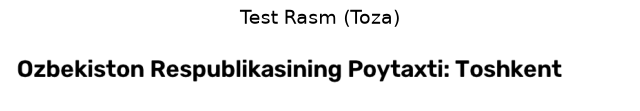

True

In [5]:
# Test uchun oddiy rasm yaratamiz (yoki o'zimizning rasmimizni yuklaymiz)
def create_test_image(text='Hello OCR World! 123', size=(900, 100), noise=False):
    """Test uchun matnli rasm yaratadi"""
    img = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255  # oq fon
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, text, (10, 65), font, 1.2, (0, 0, 0), 2)
    if noise:
        noise_arr = np.random.randint(0, 80, img.shape, dtype=np.uint8)
        img = cv2.add(img, noise_arr)
    return img

# Toza rasm yaratamiz
clean_img1 = create_test_image('Ozbekiston Respublikasining Poytaxti: Toshkent')

plt.figure(figsize=(8, 2))
plt.imshow(cv2.cvtColor(clean_img1, cv2.COLOR_BGR2RGB))
plt.title('Test Rasm (Toza)', fontsize=14)
plt.axis('off')
plt.show()

cv2.imwrite('clean_img1.jpeg', clean_img1)   # saqlash yaratilgan rasmni

✅ Rasm yuklandi: test_ocr.jpeg


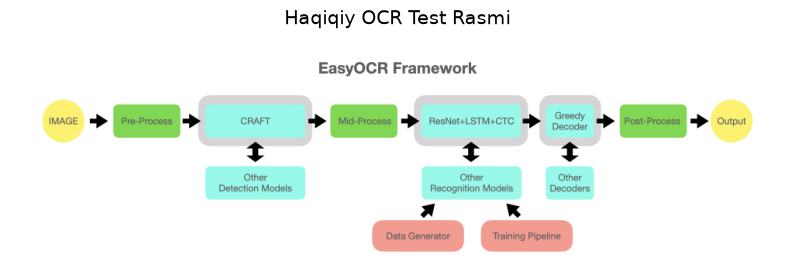

In [6]:
# Haqiqiy OCR test rasmini internetdan yuklab olamiz
import urllib.request

IMAGE_URL = 'https://raw.githubusercontent.com/JaidedAI/EasyOCR/master/examples/easyocr_framework.jpeg'

# Yuklab olamiz
urllib.request.urlretrieve(IMAGE_URL, 'test_ocr.jpeg')
print('✅ Rasm yuklandi: test_ocr.jpeg')

# O'qib ko'rsatamiz
clean_img2 = cv2.imread('test_ocr.jpeg')

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(clean_img2, cv2.COLOR_BGR2RGB))
plt.title('Haqiqiy OCR Test Rasmi', fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
# # Haqiqiy OCR test rasmini internetdan yuklab olish

# import urllib.request
# import cv2
# import matplotlib.pyplot as plt

# # GitHub sahifasi emas, RAW rasm URL
# IMAGE_URL = (
#     'https://raw.githubusercontent.com/'
#     'JaidedAI/EasyOCR/master/examples/easyocr_framework.jpeg'
# )

# # JPEG rasm bo'lgani uchun .jpeg nomi bilan saqlash
# IMAGE_PATH = 'test_ocr.jpeg'

# # Rasmni yuklab olish
# urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

# print(f'✅ Rasm yuklandi: {IMAGE_PATH}')

# # Rasmni OpenCV bilan o'qish
# clean_img = cv2.imread(IMAGE_PATH)

# # Rasm haqiqatan o'qilganini tekshirish
# if clean_img is None:
#     raise ValueError(
#         "Rasm OpenCV orqali o'qilmadi. URL yoki faylni tekshirish kerak."
#     )

# print("✅ Rasm OpenCV orqali muvaffaqiyatli o'qildi")
# print("Rasm o'lchami:", clean_img.shape)

# # OpenCV BGR formatida o'qiydi,
# # Matplotlib esa RGB formatini kutadi
# clean_img_rgb = cv2.cvtColor(
#     clean_img,
#     cv2.COLOR_BGR2RGB
# )

# # Rasmni ko'rsatish
# plt.figure(figsize=(10, 4))

# plt.imshow(clean_img_rgb)

# plt.title(
#     'Haqiqiy OCR Test Rasmi',
#     fontsize=14
# )

# plt.axis('off')

# plt.show()

✅ Rasm yuklandi!
   Hajmi: 900x100 px


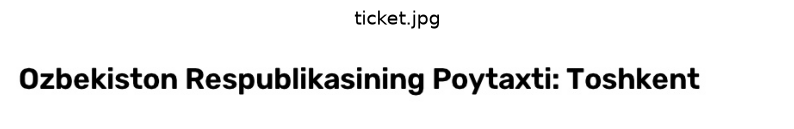

📋 OCR Natijalari:
--------------------------------------------------
  Matn     : Ozbekiston Respublikasining Poytaxti: Toshkent
  Ishonch  : 97.89%
  BBox     : [[np.int32(4), np.int32(29)], [np.int32(808), np.int32(29)], [np.int32(808), np.int32(80)], [np.int32(4), np.int32(80)]]
--------------------------------------------------


In [7]:
# O'z rasmingizni yuklash
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = r'C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\3 dars\clean_img1.jpeg'

# Yuklab ko'rsatamiz
clean_img1 = cv2.imread(IMAGE_PATH)

if clean_img1 is None:
    print('❌ Rasm topilmadi! Path tekshiring.')
else:
    print('✅ Rasm yuklandi!')
    print(f'   Hajmi: {clean_img1.shape[1]}x{clean_img1.shape[0]} px')
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(clean_img1, cv2.COLOR_BGR2RGB))
    plt.title('ticket.jpg', fontsize=14)
    plt.axis('off')
    plt.show()
    

# OCR natijasini ko'rish
results1 = reader.readtext(clean_img1)

print('📋 OCR Natijalari:')
print('-' * 50)
for (bbox, text, confidence) in results1:
    print(f'  Matn     : {text}')
    print(f'  Ishonch  : {confidence:.2%}')
    print(f'  BBox     : {bbox}')
    print('-' * 50)


✅ Rasm yuklandi!
   Hajmi: 1000x300 px


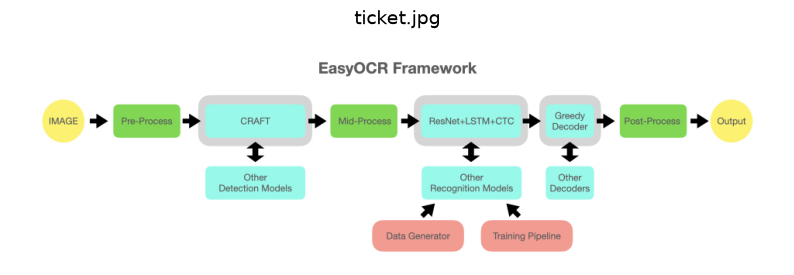

📋 OCR Natijalari:
--------------------------------------------------
  Matn     : EasyOCR Framework
  Ishonch  : 99.80%
  BBox     : [[np.int32(393), np.int32(31)], [np.int32(606), np.int32(31)], [np.int32(606), np.int32(61)], [np.int32(393), np.int32(61)]]
--------------------------------------------------
  Matn     : IMAGE
  Ishonch  : 99.94%
  BBox     : [[np.int32(49), np.int32(107)], [np.int32(91), np.int32(107)], [np.int32(91), np.int32(123)], [np.int32(49), np.int32(123)]]
--------------------------------------------------
  Matn     : Pre-Process
  Ishonch  : 85.08%
  BBox     : [[np.int32(143), np.int32(106)], [np.int32(213), np.int32(106)], [np.int32(213), np.int32(124)], [np.int32(143), np.int32(124)]]
--------------------------------------------------
  Matn     : CRAFT
  Ishonch  : 99.92%
  BBox     : [[np.int32(297), np.int32(107)], [np.int32(339), np.int32(107)], [np.int32(339), np.int32(123)], [np.int32(297), np.int32(123)]]
--------------------------------------------

In [8]:
# O'z rasmingizni yuklash
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = r'C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\3 dars\test_ocr.jpeg'

# Yuklab ko'rsatamiz
clean_img2 = cv2.imread(IMAGE_PATH)

if clean_img2 is None:
    print('❌ Rasm topilmadi! Path tekshiring.')
else:
    print('✅ Rasm yuklandi!')
    print(f'   Hajmi: {clean_img2.shape[1]}x{clean_img2.shape[0]} px')
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(clean_img2, cv2.COLOR_BGR2RGB))
    plt.title('ticket.jpg', fontsize=14)
    plt.axis('off')
    plt.show()
    

# OCR natijasini ko'rish
results2 = reader.readtext(clean_img2)

print('📋 OCR Natijalari:')
print('-' * 50)
for (bbox, text, confidence) in results2:
    print(f'  Matn     : {text}')
    print(f'  Ishonch  : {confidence:.2%}')
    print(f'  BBox     : {bbox}')
    print('-' * 50)


✅ Rasm yuklandi!
   Hajmi: 370x370 px


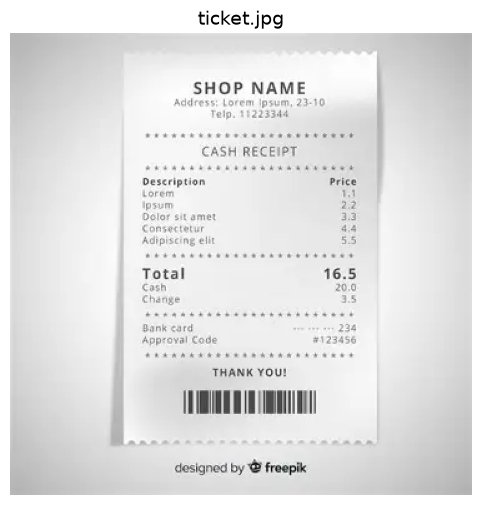

📋 OCR Natijalari:
--------------------------------------------------
  Matn     : SHOP NAME
  Ishonch  : 94.55%
  BBox     : [[np.int32(145), np.int32(37)], [np.int32(239), np.int32(37)], [np.int32(239), np.int32(53)], [np.int32(145), np.int32(53)]]
--------------------------------------------------
  Matn     : Addrot
  Ishonch  : 10.73%
  BBox     : [[np.int32(130), np.int32(52)], [np.int32(164), np.int32(52)], [np.int32(164), np.int32(60)], [np.int32(130), np.int32(60)]]
--------------------------------------------------
  Matn     : Intum / !c
  Ishonch  : 23.63%
  BBox     : [[np.int32(200), np.int32(52)], [np.int32(252), np.int32(52)], [np.int32(252), np.int32(60)], [np.int32(200), np.int32(60)]]
--------------------------------------------------
  Matn     : 114
  Ishonch  : 6.69%
  BBox     : [[np.int32(184), np.int32(60)], [np.int32(224), np.int32(60)], [np.int32(224), np.int32(68)], [np.int32(184), np.int32(68)]]
--------------------------------------------------
  Matn     :

In [9]:
# O'z rasmingizni yuklash
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = r'C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\3 dars\chek.webp'

# Yuklab ko'rsatamiz
clean_img3 = cv2.imread(IMAGE_PATH)

if clean_img3 is None:
    print('❌ Rasm topilmadi! Path tekshiring.')
else:
    print('✅ Rasm yuklandi!')
    print(f'   Hajmi: {clean_img3.shape[1]}x{clean_img3.shape[0]} px')
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(clean_img3, cv2.COLOR_BGR2RGB))
    plt.title('ticket.jpg', fontsize=14)
    plt.axis('off')
    plt.show()
    
# OCR natijasini ko'rish
results3 = reader.readtext(clean_img3)

print('📋 OCR Natijalari:')
print('-' * 50)
for (bbox, text, confidence) in results3:
    print(f'  Matn     : {text}')
    print(f'  Ishonch  : {confidence:.2%}')
    print(f'  BBox     : {bbox}')
    print('-' * 50)

✅ Rasm yuklandi!
   Hajmi: 459x316 px


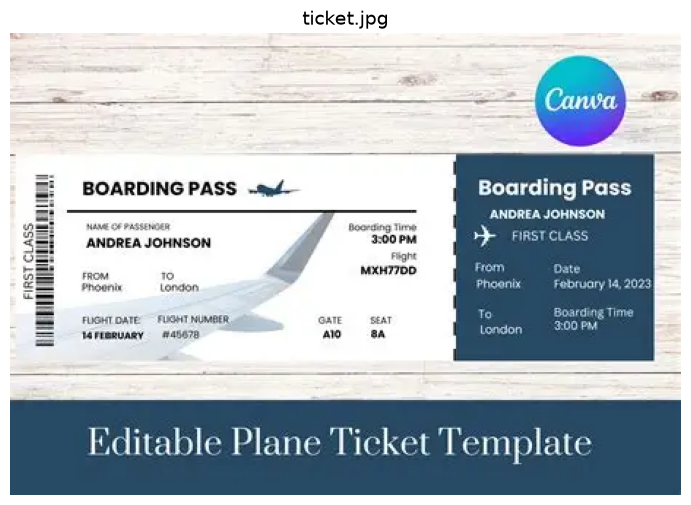

📋 OCR Natijalari:
--------------------------------------------------
  Matn     : Canva
  Ishonch  : 88.10%
  BBox     : [[np.int32(363), np.int32(35)], [np.int32(419), np.int32(35)], [np.int32(419), np.int32(55)], [np.int32(363), np.int32(55)]]
--------------------------------------------------
  Matn     : BOARDING PASS
  Ishonch  : 78.98%
  BBox     : [[np.int32(49), np.int32(99)], [np.int32(159), np.int32(99)], [np.int32(159), np.int32(115)], [np.int32(49), np.int32(115)]]
--------------------------------------------------
  Matn     : Boarding Pass
  Ishonch  : 99.81%
  BBox     : [[np.int32(315), np.int32(92)], [np.int32(430), np.int32(92)], [np.int32(430), np.int32(118)], [np.int32(315), np.int32(118)]]
--------------------------------------------------
  Matn     : ANDREA JOHNSON
  Ishonch  : 63.59%
  BBox     : [[np.int32(327), np.int32(119)], [np.int32(411), np.int32(119)], [np.int32(411), np.int32(131)], [np.int32(327), np.int32(131)]]
---------------------------------------

In [10]:
# O'z rasmingizni yuklash
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = r'C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\3 dars\airport chipta.webp'

# Yuklab ko'rsatamiz
clean_img4 = cv2.imread(IMAGE_PATH)

if clean_img4 is None:
    print('❌ Rasm topilmadi! Path tekshiring.')
else:
    print('✅ Rasm yuklandi!')
    print(f'   Hajmi: {clean_img4.shape[1]}x{clean_img4.shape[0]} px')
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(clean_img4, cv2.COLOR_BGR2RGB))
    plt.title('ticket.jpg', fontsize=14)
    plt.axis('off')
    plt.show()
    
    
# OCR natijasini ko'rish
results4 = reader.readtext(clean_img4)

print('📋 OCR Natijalari:')
print('-' * 50)
for (bbox, text, confidence) in results4:
    print(f'  Matn     : {text}')
    print(f'  Ishonch  : {confidence:.2%}')
    print(f'  BBox     : {bbox}')
    print('-' * 50)

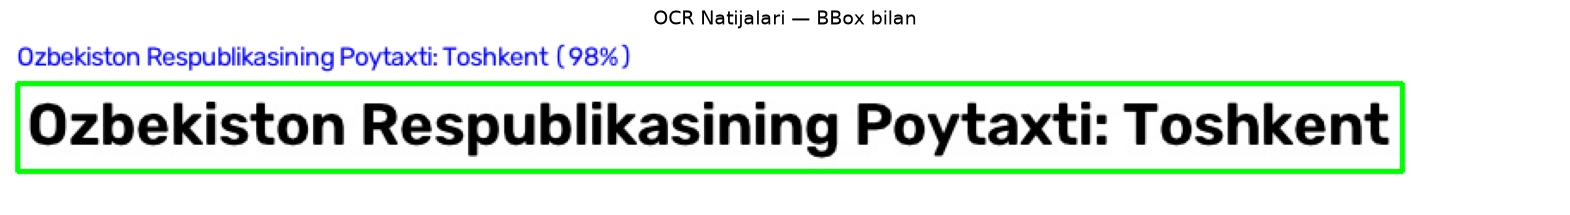

In [11]:
# BBox (Bounding Box) chizish
def draw_ocr_results(image, results):
    """OCR natijalarini rasmda ko'rsatadi"""
    img_copy1 = image.copy()
    for (bbox, text, confidence) in results:
        # BBox nuqtalarini int ga o'tkazamiz
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_copy1, [pts], True, (0, 255, 0), 2)
        # Matn va ishonch darajasini yozamiz
        x, y = pts[0]
        label = f'{text} ({confidence:.0%})'
        cv2.putText(img_copy1, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img_copy1

annotated1 = draw_ocr_results(clean_img1, results1)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(annotated1, cv2.COLOR_BGR2RGB))
plt.title('OCR Natijalari — BBox bilan', fontsize=14)
plt.axis('off')
plt.show()

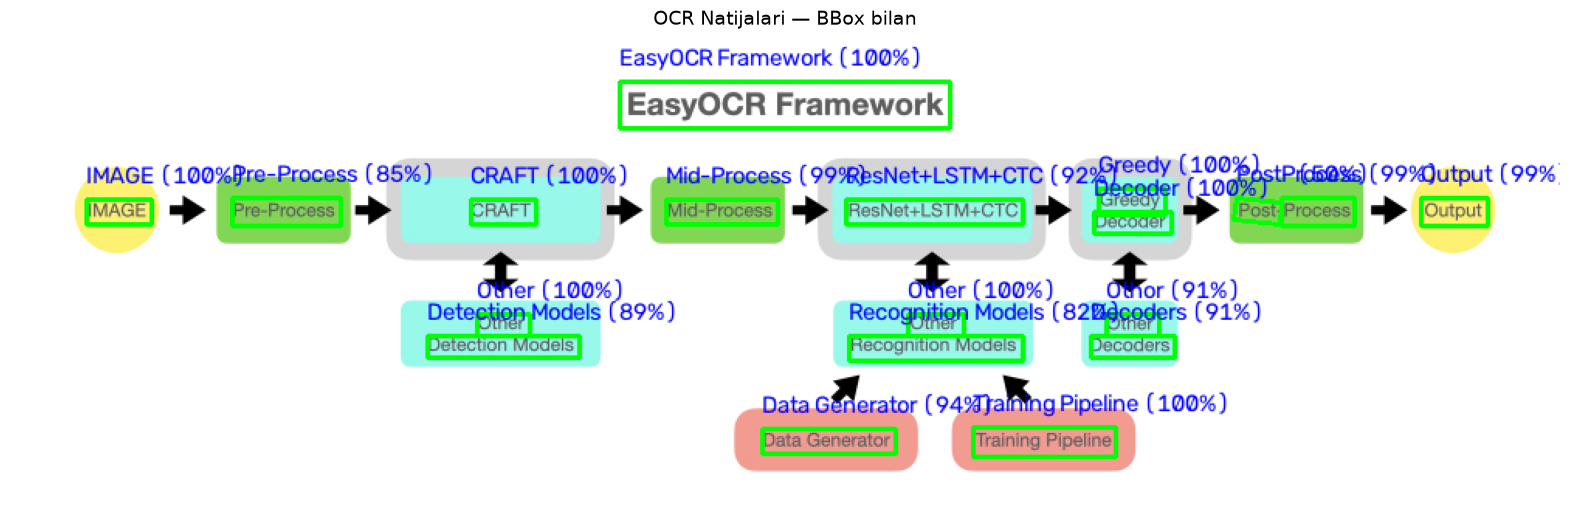

In [12]:
# BBox (Bounding Box) chizish
def draw_ocr_results(image, results):
    """OCR natijalarini rasmda ko'rsatadi"""
    img_copy2 = image.copy()
    for (bbox, text, confidence) in results:
        # BBox nuqtalarini int ga o'tkazamiz
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_copy2, [pts], True, (0, 255, 0), 2)
        # Matn va ishonch darajasini yozamiz
        x, y = pts[0]
        label = f'{text} ({confidence:.0%})'
        cv2.putText(img_copy2, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img_copy2

annotated2 = draw_ocr_results(clean_img2, results2)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(annotated2, cv2.COLOR_BGR2RGB))
plt.title('OCR Natijalari — BBox bilan', fontsize=14)
plt.axis('off')
plt.show()

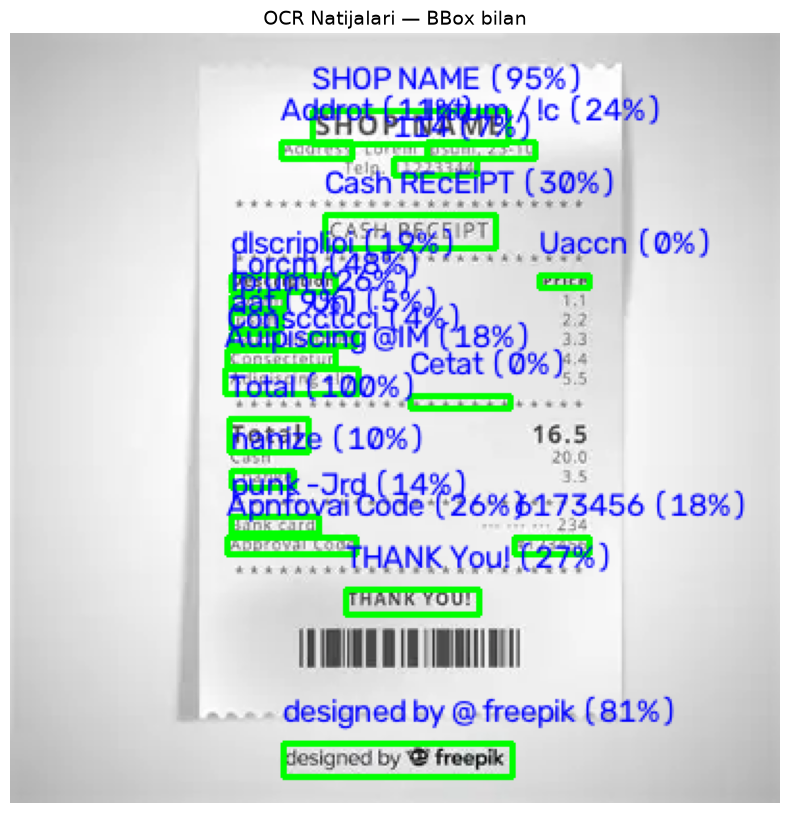

In [13]:
# BBox (Bounding Box) chizish
def draw_ocr_results(image, results):
    """OCR natijalarini rasmda ko'rsatadi"""
    img_copy3 = image.copy()
    for (bbox, text, confidence) in results:
        # BBox nuqtalarini int ga o'tkazamiz
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_copy3, [pts], True, (0, 255, 0), 2)
        # Matn va ishonch darajasini yozamiz
        x, y = pts[0]
        label = f'{text} ({confidence:.0%})'
        cv2.putText(img_copy3, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img_copy3

annotated3 = draw_ocr_results(clean_img3, results3)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(annotated3, cv2.COLOR_BGR2RGB))
plt.title('OCR Natijalari — BBox bilan', fontsize=14)
plt.axis('off')
plt.show()

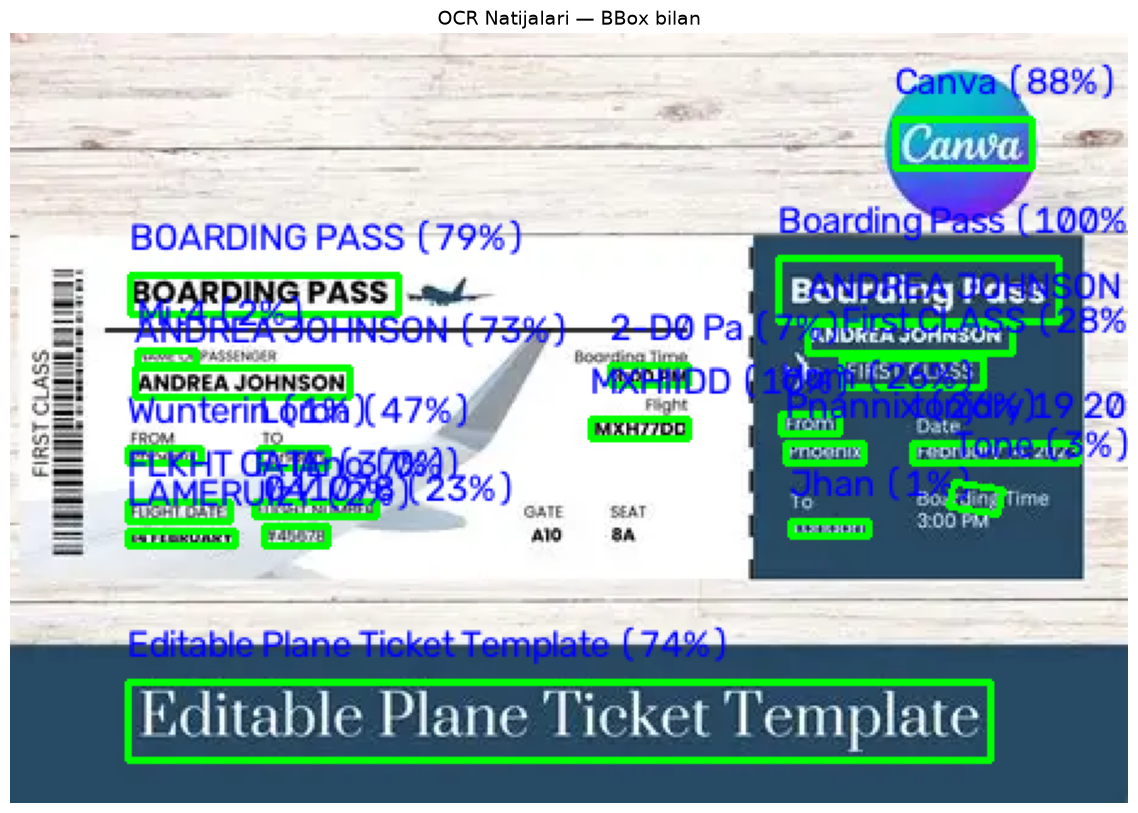

In [14]:
# BBox (Bounding Box) chizish
def draw_ocr_results(image, results):
    """OCR natijalarini rasmda ko'rsatadi"""
    img_copy4 = image.copy()
    for (bbox, text, confidence) in results:
        # BBox nuqtalarini int ga o'tkazamiz
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_copy4, [pts], True, (0, 255, 0), 2)
        # Matn va ishonch darajasini yozamiz
        x, y = pts[0]
        label = f'{text} ({confidence:.0%})'
        cv2.putText(img_copy4, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img_copy4

annotated4 = draw_ocr_results(clean_img4, results4)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(annotated4, cv2.COLOR_BGR2RGB))
plt.title('OCR Natijalari — BBox bilan', fontsize=14)
plt.axis('off')
plt.show()

---
## 3.Preprocessing Funktsiyalari

**2ta darsda o'rgangan barcha preprocessing usullarini funksiya sifatida yozamiz**

In [15]:
# =============================================
# PREPROCESSING KUTUBXONASI
# =============================================

def to_grayscale(image):
    """
    Rasmni kulrang (grayscale) ga o'tkazadi.
    Nega kerak: OCR matnga e'tibor beradi, rangga emas.
    """
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image


def remove_noise(image, method='gaussian'):
    """
    Shovqinni (noise) yo'q qiladi.
    method: 'gaussian', 'median', 'bilateral'
    """
    if method == 'gaussian':
        return cv2.GaussianBlur(image, (5, 5), 0)
    elif method == 'median':
        return cv2.medianBlur(image, 5)
    elif method == 'bilateral':
        return cv2.bilateralFilter(image, 9, 75, 75)
    return image


def binarize(image, method='otsu'):
    """
    Rasmni qora-oq (binary) ga o'tkazadi.
    method: 'otsu', 'adaptive', 'global'
    """
    gray = to_grayscale(image)
    if method == 'otsu':
        _, binary = cv2.threshold(gray, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif method == 'adaptive':
        binary = cv2.adaptiveThreshold(gray, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)
    elif method == 'global':
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    return binary


def deskew(image):
    """
    Qiyshiq rasmni to'g'rilaydi (deskewing).
    Hough Transform asosida burchak topadi.
    """
    gray = to_grayscale(image)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)
    
    if lines is None:
        return image  # Chiziq topilmasa o'zgarishsiz qaytaradi
    
    angles = []
    for line in lines:
        rho, theta = line[0]
        angle = (theta * 180 / np.pi) - 90
        if abs(angle) < 45:
            angles.append(angle)
    
    if not angles:
        return image
    
    median_angle = np.median(angles)
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, median_angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    print(f'   Topilgan burchak: {median_angle:.2f}°')
    return rotated


def enhance_contrast(image):
    """
    CLAHE yordamida kontrastni oshiradi.
    """
    gray = to_grayscale(image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)




In [16]:
def full_preprocessing_pipeline(image, verbose=True):
    """
    To'liq preprocessing pipeline:
    Grayscale → Deskew → Denoise → Binarize → Contrast
    """
    if verbose:
        print('🔄 Preprocessing boshlandi...')
    
    # 1. Grayscale
    gray = to_grayscale(image)
    if verbose: print('  ✅ 1. Grayscale')
    
    # 2. Deskew
    deskewed = deskew(gray)
    if verbose: print('  ✅ 2. Deskew')
    
    # 3. Noise removal
    denoised = remove_noise(deskewed, method='gaussian')
    if verbose: print('  ✅ 3. Noise removal')
    
    # 4. Binarization
    binary = binarize(denoised, method='otsu')
    if verbose: print('  ✅ 4. Binarization (Otsu)')
    
    if verbose:
        print('🎉 Preprocessing tugadi!')
    
    return binary


print('✅ Barcha preprocessing funktsiyalari yuklandi!')

✅ Barcha preprocessing funktsiyalari yuklandi!


---
## 4chi. Before vs After Taqqoslash

**Maqsad:** Preprocessing OCR aniqligini qanday oshirishini ko'rsatish

🔄 Preprocessing boshlandi...
  ✅ 1. Grayscale
   Topilgan burchak: -5.00°
  ✅ 2. Deskew
  ✅ 3. Noise removal
  ✅ 4. Binarization (Otsu)
🎉 Preprocessing tugadi!


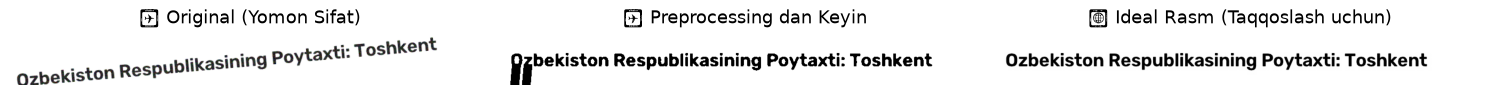

In [17]:
# Yomon sifatli rasm yaratamiz (shovqinli + qiyshiq)
noisy_img = create_test_image('Ozbekiston Respublikasining Poytaxti: Toshkent', noise=True)

# Biroz buraylash
h, w = noisy_img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 5, 1.0)  # 5 gradus burish
skewed_img = cv2.warpAffine(noisy_img, M, (w, h), borderValue=(255, 255, 255))

# Preprocessing qo'llash
processed_img = full_preprocessing_pipeline(skewed_img)

# Ko'rsatish
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cv2.cvtColor(skewed_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('❌ Original (Yomon Sifat)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(processed_img, cmap='gray')
axes[1].set_title('✅ Preprocessing dan Keyin', fontsize=13)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(clean_img1, cv2.COLOR_BGR2RGB))
axes[2].set_title('🔵 Ideal Rasm (Taqqoslash uchun)', fontsize=13)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# OCR natijalarini taqqoslash
def run_ocr_and_show(image, title):
    """OCR ishlatib natijani chiqaradi"""
    results = reader.readtext(image)
    full_text = ' '.join([text for (_, text, _) in results])
    avg_conf = np.mean([conf for (_, _, conf) in results]) if results else 0
    print(f'\n📌 {title}')
    print(f'   Topilgan matn  : "{full_text}"')
    print(f'   O\'rtacha ishonch: {avg_conf:.2%}')
    return full_text, avg_conf

# 1. Yomon rasmda OCR
text_bad, conf_bad = run_ocr_and_show(skewed_img, 'Preprocessing QILINMAGAN rasm')

# 2. Preprocessingdan keyin OCR
text_good, conf_good = run_ocr_and_show(processed_img, 'Preprocessing QILINGAN rasm')

# 3. Toza rasmda OCR
text_clean, conf_clean = run_ocr_and_show(clean_img1, 'Toza (ideal) rasm')

# Natija jadvali
print('\n' + '='*55)
print(f'{"Variant":<30} {"Ishonch":>10}')
print('='*55)
print(f'{"❌ Preprocessing siz":<30} {conf_bad:>10.2%}')
print(f'{"✅ Preprocessing bilan":<30} {conf_good:>10.2%}')
print(f'{"🔵 Ideal rasm":<30} {conf_clean:>10.2%}')
print('='*55)
print(f'\n📈 Yaxshilanish: +{(conf_good - conf_bad):.2%}')


📌 Preprocessing QILINMAGAN rasm
   Topilgan matn  : "Poytaxti: Toshkent Ozbekiston Respublikasining""
   O'rtacha ishonch: 77.40%

📌 Preprocessing QILINGAN rasm
   Topilgan matn  : "Pzbekiston Respublikasining Poytaxti: Toshkent"
   O'rtacha ishonch: 91.50%

📌 Toza (ideal) rasm
   Topilgan matn  : "Ozbekiston Respublikasining Poytaxti: Toshkent"
   O'rtacha ishonch: 97.89%

Variant                           Ishonch
❌ Preprocessing siz                77.40%
✅ Preprocessing bilan              91.50%
🔵 Ideal rasm                       97.89%

📈 Yaxshilanish: +14.10%


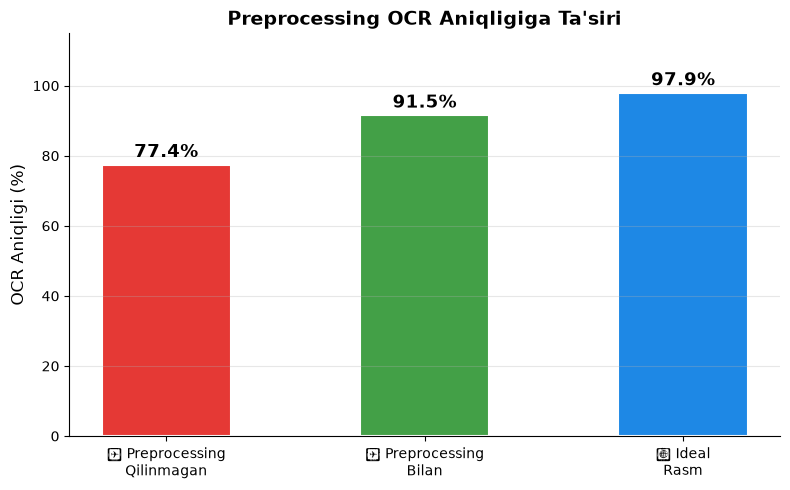

In [22]:
# Bar chart — aniqlik taqqoslash
labels = ['❌ Preprocessing\nQilinmagan', '✅ Preprocessing\nBilan', '🔵 Ideal\nRasm']
values = [conf_bad * 100, conf_good * 100, conf_clean * 100]
colors = ['#E53935', '#43A047', '#1E88E5']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('OCR Aniqligi (%)', fontsize=12)
ax.set_title('Preprocessing OCR Aniqligiga Ta\'siri', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()